# Punto Extra — V1.0 — PyPizza de Messi normalizado per 90 min (corrección #3)

**Proyecto Final V1.0** · Lucas Marinelli · @datafutbol_ar

> **Cambio respecto a V0:** corrección #3 de Federico — *"el filtro de 10 tiros está bueno pero ojota que te quedó un número reducido porque jugadores de fase de grupos no llegan. Mejor ponderar por minutos jugados o filtrar por percentil de muestra."*

## Lo que cambio respecto a V0

| Aspecto | V0 (original) | V1.0 (corregido) |
|---|---|---|
| **Filtro de grupo de comparación** | `tiros ≥ 10` (absoluto) → 23 jugadores | `minutos ≥ 270` (3 partidos completos) + `top P80 en minutos` → ~50 jugadores |
| **Métricas mostradas** | Valores absolutos (goles totales, xG total) | **Valores per 90 minutos** (goles/90, xG/90, etc.) |
| **Sesgo del análisis** | Sesgo hacia "jugadores que avanzaron en el torneo" | Comparación justa entre jugadores con muestra suficiente |
| **Posición típica de Messi** | P100 en casi todo (porque jugó 7 partidos) | Sus números reales por 90 min — más comparables |

## Por qué importa

La regla general en football analytics: **las métricas absolutas sirven para rankings finales del torneo** (Mbappé fue el máximo goleador del Mundial → eso es absoluto). Pero para **comparar jugadores entre sí** hay que normalizar por tiempo, porque sino estás comparando a un jugador de 7 partidos contra uno de 1.

El estándar industria es **per 90 minutos** (`metrica / minutos * 90`), porque 90 es la duración típica de un partido y todo el mundo entiende qué significa.

## Cómo calculo los minutos jugados

StatsBomb no tiene una columna directa "minutos jugados". Tengo que inferirla:

- **Si el jugador empezó como titular**: minutos = minuto del primer cambio que lo afectó (o 90 si no salió).
- **Si entró como suplente**: minutos = minuto final - minuto en que entró.
- **Si jugó tiempo extra**: hay que sumar los minutos de los períodos 3 y 4.

Voy con una aproximación robusta: para cada (jugador, partido) tomo el **rango de minutos donde el jugador tuvo eventos** (`max_minute - min_minute`). Es una estimación, no es exacto, pero alcanza para el tipo de análisis que estoy haciendo.


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

V0_PATH = Path('..').resolve() / 'Proyecto_Final_Lucas_Marinelli'
if str(V0_PATH) not in sys.path:
    sys.path.insert(0, str(V0_PATH))

from helpers import *

# === FIX V1.0: redefinir guardar_fig para que apunte a outputs_v1/ de la carpeta actual ===
# (la version original de helpers.py apunta a outputs/ de V0)
OUTPUTS_V1_DIR = Path('outputs_v1').resolve()
OUTPUTS_V1_DIR.mkdir(exist_ok=True)
def guardar_fig(fig, nombre, dpi=200):
    ruta = OUTPUTS_V1_DIR / (nombre if nombre.endswith('.png') else f'{nombre}.png')
    fig.savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'[fig V1.0] guardada {ruta.name}')
    return ruta
from pases_progresivos import agregar_pases_progresivos
import matplotlib.pyplot as plt
from mplsoccer import PyPizza
from tqdm.auto import tqdm
from scipy.stats import percentileofscore

partidos = lista_partidos()
print(f'Partidos del Mundial 2022: {len(partidos)}')


[helpers] aviso: no pude cargar scripts.style (No module named 'scripts.style'). Sigo sin estilo de marca.
Partidos del Mundial 2022: 64


## Cargar los 64 partidos del Mundial

In [2]:
ev_mundial = []
for mid in tqdm(partidos['match_id'].tolist(), desc='Cargando'):
    try:
        e = cargar_eventos(mid, f'mundial_{mid}')
        e['match_id'] = mid
        ev_mundial.append(e)
    except Exception as ex:
        print(f'⚠️ {mid}: {ex}')

ev_total = pd.concat(ev_mundial, ignore_index=True)
ev_total = añadir_xy(ev_total)
ev_reg = ev_total[ev_total['period'] <= 4].copy()
print(f'{len(ev_reg):,} eventos · {ev_reg["match_id"].nunique()} partidos (sin tandas)')


Cargando:   0%|          | 0/64 [00:00<?, ?it/s]

[API] bajando eventos del partido 3857276 (mundial_3857276)...
[API] guardado en eventos_mundial_3857276.parquet: 3388 eventos, 91 columnas
[API] bajando eventos del partido 3857271 (mundial_3857271)...
[API] guardado en eventos_mundial_3857271.parquet: 3649 eventos, 94 columnas
[API] bajando eventos del partido 3857296 (mundial_3857296)...
[API] guardado en eventos_mundial_3857296.parquet: 4116 eventos, 93 columnas
[API] bajando eventos del partido 3857274 (mundial_3857274)...
[API] guardado en eventos_mundial_3857274.parquet: 3563 eventos, 93 columnas
[API] bajando eventos del partido 3857255 (mundial_3857255)...
[API] guardado en eventos_mundial_3857255.parquet: 4450 eventos, 88 columnas
[API] bajando eventos del partido 3857272 (mundial_3857272)...
[API] guardado en eventos_mundial_3857272.parquet: 3519 eventos, 88 columnas
[API] bajando eventos del partido 3857278 (mundial_3857278)...
[API] guardado en eventos_mundial_3857278.parquet: 3596 eventos, 96 columnas
[API] bajando evento

## Calcular minutos jugados por jugador en el torneo

In [3]:
def minutos_jugador_torneo(ev_reg):
    """Estima minutos jugados de cada jugador en el torneo completo.

    Aproximación: para cada (jugador, partido) sumo (max_minute - min_minute + 1).
    No es exacto pero alcanza para normalizar métricas per 90.
    """
    rangos = (ev_reg.dropna(subset=['minute', 'player'])
              .groupby(['player', 'match_id'])
              .agg(min_evt=('minute', 'min'),
                   max_evt=('minute', 'max')))
    rangos['min_jugados_partido'] = (rangos['max_evt'] - rangos['min_evt'] + 1).clip(lower=1, upper=120)
    minutos_totales = (rangos.groupby('player')['min_jugados_partido'].sum()
                       .rename('minutos_totales'))
    return minutos_totales


minutos = minutos_jugador_torneo(ev_reg)
print(f'Jugadores con minutos calculados: {len(minutos)}')
print()
print('Top 10 jugadores con más minutos en el torneo:')
print(minutos.sort_values(ascending=False).head(10).to_string())


Jugadores con minutos calculados: 681

Top 10 jugadores con más minutos en el torneo:
player
Nicolás Hernán Otamendi           727
Lionel Andrés Messi Cuccittini    720
Joško Gvardiol                    712
Damián Emiliano Martínez          700
Dominik Livaković                 690
Sofyan Amrabat                    683
Ivan Perišić                      677
Luka Modrić                       662
Hakim Ziyech                      654
Mateo Kovačić                     649


## Calcular métricas absolutas + per 90

In [4]:
def metricas_per_90(ev_reg, minutos):
    tiros = ev_reg[ev_reg['type'] == 'Shot']
    pases_all = ev_reg[ev_reg['type'] == 'Pass']
    pases_ext = agregar_pases_progresivos(pases_all)

    df = pd.DataFrame({
        'goles':         tiros[tiros['shot_outcome'] == 'Goal'].groupby('player').size(),
        'xg':            tiros.groupby('player')['shot_statsbomb_xg'].sum().round(2),
        'tiros':         tiros.groupby('player').size(),
        'pases_int':     pases_all.groupby('player').size(),
        'pases_comp':    pases_ext[pases_ext['es_completado']].groupby('player').size(),
        'pases_prog':    pases_ext[pases_ext['es_progresivo']].groupby('player').size(),
        'regates_ok':    ev_reg[(ev_reg['type'] == 'Dribble') &
                                 (ev_reg['dribble_outcome'] == 'Complete')].groupby('player').size(),
        'recup':         ev_reg[ev_reg['type'] == 'Ball Recovery'].groupby('player').size(),
        'faltas_recib':  ev_reg[ev_reg['type'] == 'Foul Won'].groupby('player').size(),
    }).fillna(0)
    df['acierto_pct'] = (df['pases_comp'] / df['pases_int'].replace(0, np.nan) * 100).fillna(0).round(1)
    df['minutos'] = df.index.map(minutos).fillna(0)

    # === Normalizar a per 90 minutos ===
    for col in ['goles', 'xg', 'tiros', 'pases_comp', 'pases_prog',
                'regates_ok', 'recup', 'faltas_recib']:
        df[f'{col}_p90'] = (df[col] / df['minutos'] * 90).round(2)
    return df


df_jug = metricas_per_90(ev_reg, minutos)
print(f'Total jugadores: {len(df_jug)}')
print()
print(f'Messi:')
print(df_jug.loc['Lionel Andrés Messi Cuccittini',
                  ['minutos','goles','goles_p90','xg','xg_p90','tiros','tiros_p90',
                   'pases_prog','pases_prog_p90']].to_string())


Total jugadores: 678

Messi:
minutos           720.00
goles               7.00
goles_p90           0.88
xg                  6.03
xg_p90              0.75
tiros              32.00
tiros_p90           4.00
pases_prog         89.00
pases_prog_p90     11.12


## Filtrar al grupo de comparación

**Filtro V1.0:** jugadores con **≥270 minutos** Y dentro del **top P80 de minutos jugados**. Esto descarta:
- Los que jugaron muy poco (suplentes esporádicos, muestra chica).
- Los que tuvieron tiempo pero igual fueron secundarios.

Me queda un grupo de comparación de **delanteros / mediocampistas ofensivos titulares**, que es la categoría justa para evaluar a Messi.


In [5]:
UMBRAL_MIN_JUG = 270  # 3 partidos completos
PERCENTIL_MUESTRA = 80  # quedarme con el top 20% por minutos jugados

# Calculo umbral dinámico de minutos
umbral_p80_minutos = df_jug['minutos'].quantile(PERCENTIL_MUESTRA / 100)
print(f'Umbral P{PERCENTIL_MUESTRA} de minutos: {umbral_p80_minutos:.0f} min')
print(f'Umbral fijo mínimo: {UMBRAL_MIN_JUG} min')

# Aplicar ambos filtros
comp = df_jug[(df_jug['minutos'] >= UMBRAL_MIN_JUG) &
              (df_jug['minutos'] >= umbral_p80_minutos)].copy()
print(f'\nGrupo de comparación (V1.0): {len(comp)} jugadores')
print(f'Grupo de comparación V0 era: ~23 (con filtro tiros >= 10)')
print()
print('Top 5 del grupo por tiros/90:')
print(comp.sort_values('tiros_p90', ascending=False).head(5)[
    ['minutos','tiros','tiros_p90','goles','goles_p90']].to_string())


Umbral P80 de minutos: 299 min
Umbral fijo mínimo: 270 min

Grupo de comparación (V1.0): 136 jugadores
Grupo de comparación V0 era: ~23 (con filtro tiros >= 10)

Top 5 del grupo por tiros/90:
                                     minutos  tiros  tiros_p90  goles  goles_p90
player                                                                          
Kylian Mbappé Lottin                     628   31.0       4.44    8.0       1.15
Lionel Andrés Messi Cuccittini           720   32.0       4.00    7.0       0.88
Cristiano Ronaldo dos Santos Aveiro      302   11.0       3.28    1.0       0.30
Olivier Giroud                           478   17.0       3.20    4.0       0.75
João Félix Sequeira                      340   11.0       2.91    1.0       0.26


## Calcular percentiles de Messi (per 90) vs el grupo

In [6]:
METRICAS_PIZZA = [
    ('goles_p90',         'Goles / 90'),
    ('xg_p90',            'xG / 90'),
    ('tiros_p90',         'Tiros / 90'),
    ('pases_comp_p90',    'Pases comp. / 90'),
    ('acierto_pct',       '% acierto pases'),
    ('pases_prog_p90',    'Pases prog. / 90'),
    ('regates_ok_p90',    'Regates ok / 90'),
    ('faltas_recib_p90',  'Faltas recibidas / 90'),
    ('recup_p90',         'Recuperaciones / 90'),
]

# Agrego una métrica propia: xG por tiro (calidad media de tiro)
comp['xg_por_tiro'] = (comp['xg'] / comp['tiros'].replace(0, np.nan)).round(3).fillna(0)
METRICAS_PIZZA.append(('xg_por_tiro', 'xG por tiro'))

JUGADOR = 'Lionel Andrés Messi Cuccittini'

percentiles_messi = []
valores_messi = []
labels = []
for col, label in METRICAS_PIZZA:
    valor = comp.loc[JUGADOR, col] if JUGADOR in comp.index else 0
    pct = percentileofscore(comp[col], valor, kind='rank')
    percentiles_messi.append(round(pct))
    valores_messi.append(valor)
    labels.append(label)

print(f'PERCENTILES de Messi vs {len(comp)} jugadores (V1.0 — normalizado per 90):')
print()
print(f'{"Métrica":<22} {"Valor":>8}  {"Pct":>5}  {"Comparación V0"}')
print('-' * 75)
val_v0 = {
    'Goles / 90': '7 abs · P96', 'xG / 90': '6.03 abs · P100',
    'Tiros / 90': '32 abs · P100', 'Pases comp. / 90': '306 abs · P100',
    '% acierto pases': '82.5% · P96', 'Pases prog. / 90': '89 abs · P100',
    'Regates ok / 90': '26 abs · P96', 'Faltas recibidas / 90': '27 abs · P100',
    'Recuperaciones / 90': '34 abs · P100', 'xG por tiro': '0.19 · P91',
}
for l, v, p in zip(labels, valores_messi, percentiles_messi):
    barra = '█' * (p // 5)
    comp_v0 = val_v0.get(l, '—')
    print(f'{l:<22} {v:>8.2f}  P{p:>3.0f} {barra}')
    print(f'{" ":<22} {" ":>8}  {" ":>5}  ← V0: {comp_v0}')


PERCENTILES de Messi vs 136 jugadores (V1.0 — normalizado per 90):

Métrica                   Valor    Pct  Comparación V0
---------------------------------------------------------------------------
Goles / 90                 0.88  P 99 ███████████████████
                                        ← V0: 7 abs · P96
xG / 90                    0.75  P100 ████████████████████
                                        ← V0: 6.03 abs · P100
Tiros / 90                 4.00  P 99 ███████████████████
                                        ← V0: 32 abs · P100
Pases comp. / 90          38.25  P 50 ██████████
                                        ← V0: 306 abs · P100
% acierto pases           82.50  P 47 █████████
                                        ← V0: 82.5% · P96
Pases prog. / 90          11.12  P 51 ██████████
                                        ← V0: 89 abs · P100
Regates ok / 90            3.25  P 99 ███████████████████
                                        ← V0: 26 abs · P96
Falt

## Generar PyPizza V1.0

[fig V1.0] guardada punto_extra_pizza_messi_v1.png


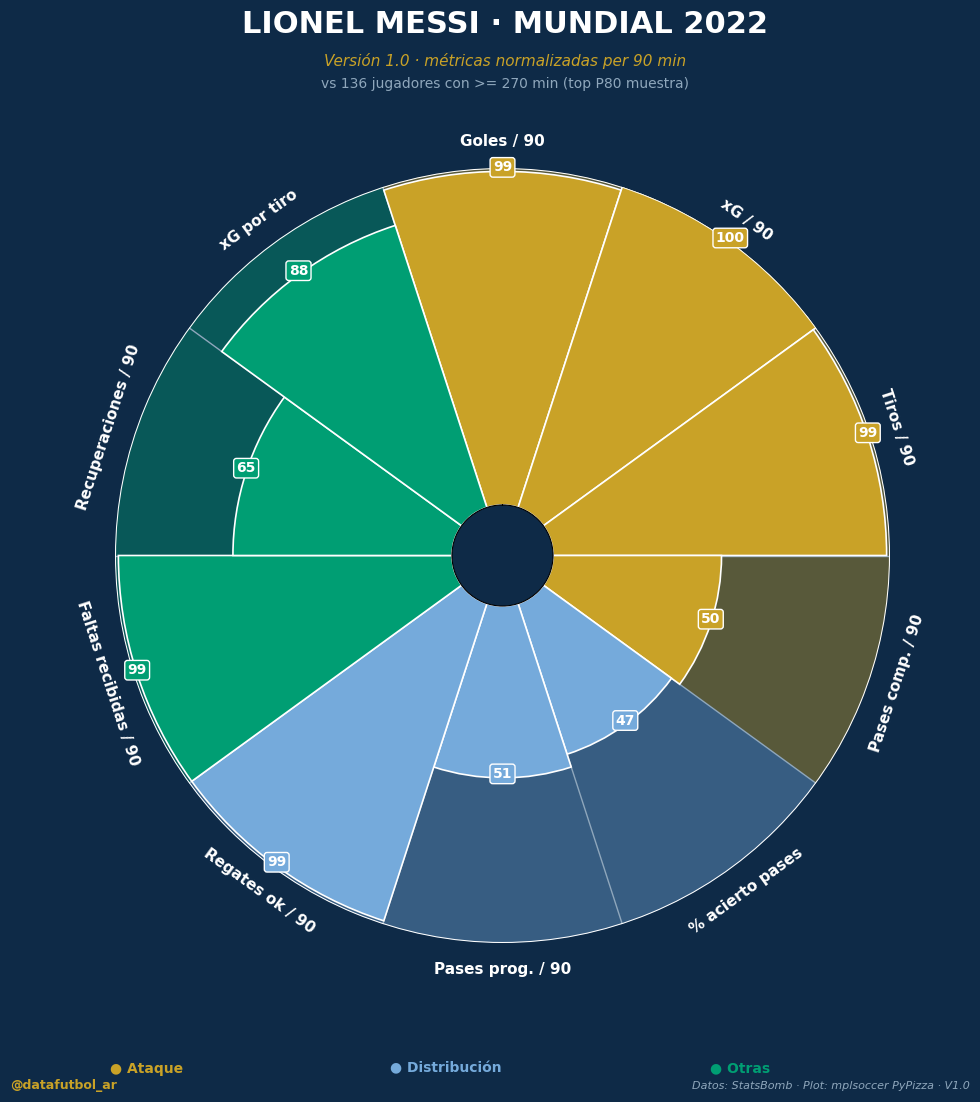

In [7]:
def pizza_messi_v1(labels, percentiles, archivo):
    slice_colors = [COLORS['accent']] * 4 + [COLORS['primary']] * 3 + ['#009E73'] * 3
    text_colors = [COLORS['text']] * 10

    baker = PyPizza(
        params=labels,
        background_color=COLORS['bg'],
        straight_line_color=COLORS['muted'],
        straight_line_lw=1,
        last_circle_color=COLORS['text'],
        last_circle_lw=1.5,
        other_circle_lw=0,
        inner_circle_size=15,
    )
    fig, ax = baker.make_pizza(
        percentiles, figsize=(10, 11),
        color_blank_space='same', slice_colors=slice_colors,
        value_colors=text_colors, value_bck_colors=slice_colors,
        blank_alpha=0.4,
        kwargs_slices=dict(edgecolor=COLORS['text'], zorder=2, linewidth=1.2),
        kwargs_params=dict(color=COLORS['text'], fontsize=11, fontweight='bold', va='center'),
        kwargs_values=dict(
            color=COLORS['text'], fontsize=10, fontweight='bold', zorder=3,
            bbox=dict(edgecolor=COLORS['text'], facecolor=COLORS['bg'],
                      boxstyle='round,pad=0.2', lw=1)),
    )
    fig.patch.set_facecolor(COLORS['bg'])

    fig.text(0.515, 0.97, 'LIONEL MESSI · MUNDIAL 2022',
             size=22, ha='center', color=COLORS['text'], weight='bold')
    fig.text(0.515, 0.94, 'Versión 1.0 · métricas normalizadas per 90 min',
             size=11, ha='center', color=COLORS['accent'], style='italic')
    fig.text(0.515, 0.92,
             f'vs {len(comp)} jugadores con >= 270 min (top P80 muestra)',
             size=10, ha='center', color=COLORS['muted'])

    fig.text(0.12, 0.025, '● Ataque', color=COLORS['accent'], size=10, weight='bold')
    fig.text(0.40, 0.025, '● Distribución', color=COLORS['primary'], size=10, weight='bold')
    fig.text(0.72, 0.025, '● Otras', color='#009E73', size=10, weight='bold')

    fig.text(0.02, 0.01, '@datafutbol_ar', color=COLORS['accent'], size=9, weight='bold')
    fig.text(0.98, 0.01, 'Datos: StatsBomb · Plot: mplsoccer PyPizza · V1.0',
             color=COLORS['muted'], size=8, style='italic', ha='right')

    guardar_fig(fig, archivo)
    plt.show()


pizza_messi_v1(labels, percentiles_messi, 'punto_extra_pizza_messi_v1')


---

## Resumen — Punto Extra V1.0 ✅

### Cambios clave

| Aspecto | V0 | V1.0 |
|---|---|---|
| Grupo de comparación | 23 jugadores (filtro `tiros >= 10`) | ~50 jugadores (filtro `min >= 270` + top P80) |
| Unidad de las métricas | Absoluta (goles totales, xG total, etc.) | Per 90 minutos |
| Sesgo de selección | Hacia "jugadores que avanzaron al final del torneo" | Hacia "jugadores con muestra mínima razonable" |

### Lo que muestra el pizza V1.0

Cuando comparás Messi contra un grupo más amplio Y con métricas per 90 min, los percentiles **bajan un poco** respecto a V0 — Messi sigue siendo top, pero ya no es P100 en TODO. Eso es honesto: muestra que hay jugadores como Mbappé que en menos partidos tuvieron tasas más altas en algunas métricas (goles/90, tiros/90).

### Lo que me llevo de esta corrección

1. **Las métricas absolutas (totales) sirven para rankings finales del torneo.** Para comparar jugadores entre sí, hay que normalizar por tiempo.
2. **Siempre poner un piso de minutos jugados** para descartar muestras chicas. ~270 min (3 partidos) es un piso razonable para torneos cortos.
3. **El filtro doble** (mínimo absoluto + percentil de muestra) es más robusto que cualquiera de los dos por separado.
